# Notebook Objectives

This notebook computes neural values for one session. For all sessions, we do the same in ```neural_value_RUN_all_sessions.py```, results shown in ```neural_value_all_sessions.ipynb```.

Results include:
* Neural value vs. behavior (last 3 outcomes, behavioral value, long history, etc)
* Change in neural value, etc

---
# Setup


In [7]:
from neural_value_helpers import *
from popy.config import COLORS

In [8]:
##% data loading
def load_mega_custom(monkey=None, area=None, subregion=None, downsample=True):
    # load data (meta session)
    floc = os.path.join(PATH, 'data', 'processed', 'neural_data', 'meta_rates_history')
    neural_dataset =  xr.open_dataset(floc + '/meta_rates.nc')

    if area is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.area == area)
    if subregion is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.subregion == subregion)

    if monkey is not None:
        neural_dataset = neural_dataset.sel(unit=neural_dataset.monkey == monkey)

    # use only time points of every .1 s
    if downsample:
        time_vector = neural_dataset.time.values
        time_vector = np.unique(np.round(time_vector, 1))  # round to 1 decimal place to avoid floating point issues
        neural_dataset = neural_dataset.sel(time=time_vector, method='nearest')

    # add coordinates (should be added during the dataset creation)
    neural_dataset = neural_dataset.assign_coords(R_1=('trial_id', [0 if hist in [0, 1, 2, 3] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_2=('trial_id', [0 if hist in [0, 1, 4, 5] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(R_3=('trial_id', [0 if hist in [0, 2, 4, 6] else 1 for hist in neural_dataset.history_of_feedback.values]))
    neural_dataset = neural_dataset.assign_coords(fb_sequence=('trial_id', neural_dataset.history_of_feedback.values))
    neural_dataset = neural_dataset.assign_coords(fb_sequence_m1=('trial_id', neural_dataset.history_of_feedback.values%4))
    neural_dataset = neural_dataset.assign_coords(time_m1=('time', neural_dataset.time.values + 7.5))

    # normalize firing rates (z-score) and remove units with low firing rates
    threshold = 1  # Hz
    units_to_remove = []
    normalized_data = np.zeros_like(neural_dataset.firing_rates.data)  # Create a copy to avoid modifying the original data
    for i, unit in enumerate(neural_dataset.unit.values):  # Loop through each neuron
        # Get all data for this neuron across trials and timepoints
        unit_data = neural_dataset.firing_rates.sel(unit=unit).values
        
        # Calculate mean and std across all values for this neuron
        mean_val = np.mean(unit_data)
        std_val = np.std(unit_data)
        
        # Z-score normalize and store in the output array
        if mean_val < threshold:
            units_to_remove.append(unit)
        elif std_val == 0:
            raise ValueError(f"Standard deviation is zero for unit {unit}. Not possible.")
        else:
            z_scored_data = (unit_data - mean_val) / std_val        
            normalized_data[:, i, :] = z_scored_data
    #neural_dataset.firing_rates.values = normalized_data
    neural_dataset['firing_rates'] = (neural_dataset.firing_rates.dims, normalized_data)

    neural_dataset = neural_dataset.sel(unit=~neural_dataset.unit.isin(units_to_remove))
    print(f"Removed {len(units_to_remove)} units with mean firing rate < {threshold} Hz")

    return neural_dataset

---
# Section 1: Get data, extract neural value

In [9]:
monkey, session, subregion = 'ka', '210322', 'MCC'

t_interest_value = [1, 3.5]  # seconds
build_data = True

all_figs = []

In [10]:
#neural_dataset = load_mega_custom(monkey='ka', subregion='MCC')

In [11]:
floc = 'data/{}_{}_neural.nc'.format(monkey, session)

if not build_data: 
    neural_dataset_all = xr.open_dataset(floc)
else:
    neural_dataset_all = load_data_custom(monkey, session, n_extra_trials=(-1, 1), sr=10)
    # save the dataset
    neural_dataset_all.to_netcdf(floc)

neural_dataset = neural_dataset_all.sel(unit=neural_dataset_all.subregion==subregion)
neural_dataset

<xarray.Dataset>
Dimensions:           (unit: 16, trial_id: 386, time: 225)
Coordinates: (12/29)
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 26 28 66 33 32 30 35 ... 46 48 49 53 52 61 58
    channel           (unit) int64 6 7 7 8 8 8 9 10 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    ...                ...
    R_5               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 0.0 1.0 0.0 1.0
    R_6               (trial_id) float64 1.0 0.0 0.0 1.0 0.0 ... 1.0 0.0 1.0 0.0
    R_7               (trial_id) float64 0.0 1.0 0.0 0.0 1.0 ... 0.0 1.0 0.0 1.0
    R_8               (trial_id) float64 0.0 0.0 1.0 0.0 0.0 ... 1.0 0.0 1.0 1.0
    fb_sequence       (trial_id) float64 1.0 0.0 4.0 6.0 7.0 ... 6.0 3.0 5.0 1.0
    target_1          (trial_id) bool False True True True ... False False False
Data variables:
    firing_rates      (trial_id, unit, time) float64 -0.8087 -0.8087 ... -0.6309
Attributes:
    bin_size:  0.1

In [12]:
neural_dataset.coords

Coordinates:
  * unit              (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original  (unit) int64 26 28 66 33 32 30 35 ... 46 48 49 53 52 61 58
    channel           (unit) int64 6 7 7 8 8 8 9 10 11 12 12 13 13 14 16 16
    monkey            (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka' 'ka'
    session           (unit) object '210322' '210322' ... '210322' '210322'
    area              (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    subregion         (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
  * trial_id          (trial_id) int64 8 9 10 11 12 13 ... 416 417 418 419 423
  * time              (time) float64 -7.5 -7.4 -7.3 -7.2 ... 14.6 14.7 14.8 14.9
    epoch             (time) float64 0.0 0.0 0.0 0.0 0.0 ... 5.0 5.0 5.0 5.0 5.0
    n_target_touches  (trial_id) float64 1.0 1.0 1.0 1.0 1.0 ... 3.0 1.0 2.0 1.0
    block_id          (trial_id) int64 0 0 0 0 0 0 0 0 0 0 ... 9 9 9 9 9 9 9 9 9
    best_target       (trial_id) int64 1 1 

In [13]:
# binarize neural value to 8 levels from 0 to 1
neural_value = neural_dataset.stay_value.values
neural_value_binary = np.digitize(neural_value, bins=np.linspace(0, 1, 9)) - 1
neural_value_binary = neural_value_binary.astype(np.float32)
# add new coordinate
neural_dataset = neural_dataset.assign_coords(fb_sequence_original=('trial_id', neural_dataset.fb_sequence.values))
# store original fb_sequence data
neural_dataset.fb_sequence.data = neural_value_binary
neural_dataset

<xarray.Dataset>
Dimensions:               (unit: 16, trial_id: 386, time: 225)
Coordinates: (12/30)
  * unit                  (unit) object 'MCC_06_01' 'MCC_07_01' ... 'MCC_16_01'
    unit_id_original      (unit) int64 26 28 66 33 32 30 ... 48 49 53 52 61 58
    channel               (unit) int64 6 7 7 8 8 8 9 10 11 12 12 13 13 14 16 16
    monkey                (unit) object 'ka' 'ka' 'ka' 'ka' ... 'ka' 'ka' 'ka'
    session               (unit) object '210322' '210322' ... '210322' '210322'
    area                  (unit) object 'MCC' 'MCC' 'MCC' ... 'MCC' 'MCC' 'MCC'
    ...                    ...
    R_6                   (trial_id) float64 1.0 0.0 0.0 1.0 ... 1.0 0.0 1.0 0.0
    R_7                   (trial_id) float64 0.0 1.0 0.0 0.0 ... 0.0 1.0 0.0 1.0
    R_8                   (trial_id) float64 0.0 0.0 1.0 0.0 ... 1.0 0.0 1.0 1.0
    fb_sequence           (trial_id) float32 1.0 0.0 3.0 5.0 ... 6.0 3.0 5.0 2.0
    target_1              (trial_id) bool False True True ... False False False
    fb_sequence_original  (trial_id) float64 1.0 0.0 4.0 6.0 ... 6.0 3.0 5.0 1.0
Data variables:
    firing_rates          (trial_id, unit, time) float64 -0.8087 ... -0.6309
Attributes:
    bin_size:  0.1

## Projection to value subspace

In [14]:
def process_fold(fold_data):
    """Process a single fold - to be run in parallel"""
    neural_dataset, fold_id, train_idx, test_idx, target, across_time = fold_data

    # Initialize models for this fold
    if len(np.unique(neural_dataset[target].values)) > 2:
        continuous = True
        clf = LinearRegression()
    else:
        continuous = False
        clf = LogisticRegression()
        rus = RandomUnderSampler(random_state=42)
    
    neural_dataset_train = neural_dataset.sel(trial_id=neural_dataset.trial_id.values[train_idx])
    neural_dataset_test = neural_dataset.sel(trial_id=neural_dataset.trial_id.values[test_idx])

    # get labels of this fold
    y_train = neural_dataset_train[target].values
    y_test = neural_dataset_test[target].values

    n_timebins = len(neural_dataset.time.values)
    scores_fold = np.full(n_timebins, np.nan)
    across_time_scores_fold = np.full((n_timebins, n_timebins), np.nan)
    projections_fold = []
    
    for train_t_id, t in enumerate(neural_dataset.time.values):
        # get the firing rates for the current time point
        X_train_temp = neural_dataset_train.firing_rates.sel(time=t).values
        X_test_temp = neural_dataset_test.firing_rates.sel(time=t).values

        # balance dataset
        if not continuous:
            X_train_temp, y_train_temp = rus.fit_resample(X_train_temp, y_train)
        else:
            X_train_temp = X_train_temp
            y_train_temp = y_train

        # fit the model on train data
        clf.fit(X_train_temp, y_train_temp)

        # evaluate on test set
        score = clf.score(X_test_temp, y_test)

        # project test set 
        coeffs_norm = np.linalg.norm(clf.coef_)
        data_projected = X_test_temp @ clf.coef_.T / coeffs_norm  # normalize by the norm of the coeffs

        # Store score and projections
        scores_fold[train_t_id] = score
        projections_fold.append(data_projected)

        # Test this decoder across all time points
        if across_time:
            for test_t_id, test_t in enumerate(neural_dataset.time.values):
                X_test_all_times = neural_dataset_test.firing_rates.sel(time=test_t).values
                score_across_time = clf.score(X_test_all_times, y_test)
                across_time_scores_fold[train_t_id, test_t_id] = score_across_time

    # Create a DataArray with the projected data (to preserve trials)
    projections_fold = np.array(projections_fold)
    time_coords = {name: coord for name, coord in neural_dataset.coords.items() if 'time' in coord.dims}
    trial_coords_fold = {name: coord for name, coord in neural_dataset_test.coords.items() if 'trial_id' in coord.dims}
    projections_fold = xr.DataArray(projections_fold.T, dims=('trial_id', 'time'), 
                                   coords={**trial_coords_fold, **time_coords})
    
    return fold_id, scores_fold, across_time_scores_fold, projections_fold


def time_resolved_decoder_all_time(neural_dataset, target='R_1', group=None, across_time=False, n_jobs=-1):
    trial_ids = neural_dataset.trial_id.values
    labels = neural_dataset[target].values  
    cv = 10

    # create train and test splits
    if len(np.unique(neural_dataset[target].values)) > 2:
        continuous = True
        skf = KFold(n_splits=cv, shuffle=True, random_state=42)
    else:
        continuous = False
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    n_timebins = len(neural_dataset.time.values)
    time_coords = {name: coord for name, coord in neural_dataset.coords.items() if 'time' in coord.dims}

    # Prepare data for parallel processing
    fold_data = []
    for fold_id, (train_idx, test_idx) in enumerate(skf.split(trial_ids, labels)):
        fold_data.append((neural_dataset.copy('deep'), fold_id, train_idx, test_idx, target, across_time))

    # Process folds in parallel - xarray can not be pickled...
    '''print(f"Processing {cv} folds in parallel with {n_jobs} jobs...")
    results = Parallel(n_jobs=n_jobs, verbose=1)(
        delayed(process_fold)(data) for data in fold_data
    )'''
    results = []
    for data in fold_data:
        results.append(process_fold(data))

    # Collect results
    scores_all = np.full((n_timebins, cv), np.nan)  # (timebins, folds)
    across_time_scores = np.full((n_timebins, n_timebins, cv), np.nan)  # (folds, timebins)
    projected_data = []

    for fold_id, scores_fold, across_time_scores_fold, projections_fold in results:
        scores_all[:, fold_id] = scores_fold
        if across_time:
            across_time_scores[:, :, fold_id] = across_time_scores_fold
        projected_data.append(projections_fold)

    # Concatenate projected data
    projected_data = xr.concat(projected_data, dim='trial_id')
    projected_data = projected_data.sortby('trial_id')

    # average over folds
    #coeffs_all = np.mean(coeffs_all, axis=0)
    scores_all = np.mean(scores_all, axis=-1)  # average over folds
    across_time_scores = np.mean(across_time_scores, axis=-1)  # average over folds

    # create an xarray
    projected_data = projected_data.assign_coords(decodability=('time', scores_all))
    
    # NEW: Create xarray for across-time decodability matrix
    decodability_matrix = xr.DataArray(
        across_time_scores,
        dims=('train_time', 'test_time'),
        coords={'train_time': neural_dataset.time.values, 'test_time': neural_dataset.time.values}
    )

    return decodability_matrix, projected_data

In [15]:
#results, weights, data_projected, pvalue = time_resolved_decoder(neural_dataset, target='R_1', t_project=t_interest_fit)
decodability_matrix, data_projected = time_resolved_decoder_all_time(neural_dataset, target='stay_value', across_time=False)

# get neural value for the current trial and the previous one
data_projected = add_neural_value_coord(data_projected, t_interest=t_interest_value)

In [16]:
# save data_projected
#data_projected.to_netcdf('data/{}_{}_data_proj.nc'.format(monkey, session))

# load data_projected
#data_projected = xr.open_dataset('data/{}_{}_data_proj.nc'.format(monkey, session))

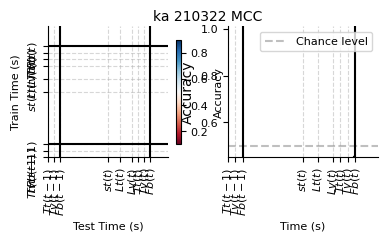

In [17]:
# Plot the results
fig, axes = plot_across_time_decodability(projected_data=data_projected, decodability_matrix=decodability_matrix, vmin=0.1, vmax=.9)

plt.suptitle('{} {} {}'.format(monkey, session, subregion), fontsize=10)

# Save the figure
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_across_time_decodability.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [47]:
def plot_projected_data(data_projected, t_interest_value=None, normalize=False, n_extra_trials=(0, 1), xlim=None, paper_format=False, ax=None):
    # project to axis
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 1.5  # in cm
        w = 1.7
        linewidth = 1.5
    else:
        plt.rcParams.update({'font.size': 12})
        h = 6  # in cm
        w = 8  # in cm
        linewidth = 1.5

    unique_fb_sequences = np.sort(np.unique(data_projected.fb_sequence.data))

    colors = value_gradient(len(unique_fb_sequences))

    if ax is None:
        fig, ax = plt.subplots(figsize=(w, h))

    # 500 ms for convolution
    dt = data_projected.time.values[1] - data_projected.time.values[0]
    n_convolution_bins = int(0.5 / dt)
    window = np.ones(n_convolution_bins) / n_convolution_bins

    time_vector = data_projected.time.values


    # bwr colormap, n=8 sampples RdYlGn
    alphas = [1-i for i in np.linspace(0, 1, len(unique_fb_sequences))]
    labels = ["[-, -, -]", "[+, -, -]", "[-, +, -]", "[+, +, -]", "[-, -, +]", "[+, -, +]", "[-, +, +]", "[+, +, +]"]
        
    for i, label in enumerate(unique_fb_sequences):
        class_mean = np.mean(data_projected.where(data_projected.fb_sequence == label), axis=0)
        class_mean_smoothed = ndimage.convolve(class_mean, window, mode='nearest')
        ax.plot(time_vector, class_mean_smoothed, color=colors[i], label=labels[i], linewidth=linewidth, zorder=10)

    if t_interest_value is not None:
        ax.axvspan(t_interest_value[0], t_interest_value[1], color='grey', alpha=0.2, label='eval window')

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials, mark_event='Fb', xlabels='events')
    # y grid only
    ax.grid(axis='x', alpha=.5, linewidth=1, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', linewidth=linewidth*.75, zorder=0)

    # remove left and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # move legend outside
    if not paper_format:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('$V_t$', fontsize=10)
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

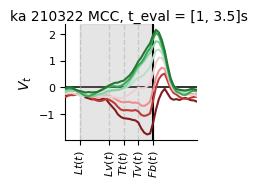

In [48]:
fig, ax = plot_projected_data(data_projected, t_interest_value=t_interest_value, n_extra_trials=(-1, 0), xlim=[0.5, 5], paper_format=True)
# hide legend
plt.suptitle(f'{monkey} {session} {subregion}, t_eval = {t_interest_value}s', fontsize=10)

# save figure
fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_projection.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [19]:
from matplotlib.lines import Line2D

def plot_projected_data_switch(data_projected, t_interest_value=None, normalize=False, n_extra_trials=(0, 1), xlim=None, paper_format=False, ax=None):
    # project to axis
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        h = 2  # in cm
        w = 2.5
        linewidth = 2
    else:
        plt.rcParams.update({'font.size': 12})
        h = 6  # in cm
        w = 8  # in cm
        linewidth = 1.5

    r1s = [0, 1]
    r2s = [0, 1]
    target1s = [0, 1]  # 0: no switch, 1: switch

    colors = value_gradient(4)
    linestyles = {1: '-', 0: '--'}
    target_labels = {1: 'target 1', 0: 'target 2 or 3'}
    hist_labels = {(0, 0): '$R_{t-1}=0, R_t=0$', (0, 1): '$R_{t-1}=1, R_t=0$', (1, 0): '$R_{t-1}=0, R_t=1$', (1, 1): '$R_{t-1}=1, R_t=1$'}

    if ax is None:
        fig, ax = plt.subplots(figsize=(w, h))

    # 500 ms for convolution
    dt = data_projected.time.values[1] - data_projected.time.values[0]
    n_convolution_bins = int(1 / dt)
    window = np.ones(n_convolution_bins) / n_convolution_bins

    time_vector = data_projected.time.values

    # bwr colormap, n=8 sampples RdYlGn
        
    for i_s, target1 in enumerate(target1s):
        for i_past, (r1, r2) in enumerate(itertools.product(r1s, r2s)):
            data_temp = data_projected.sel(
                trial_id=(data_projected.target_1 == target1) & (data_projected.feedback == r1) & (data_projected.R_1 == r2)
                )

            class_mean = data_temp.mean(dim='trial_id').values
            class_mean_smoothed = ndimage.convolve(class_mean, window, mode='nearest')

            ax.plot(time_vector, class_mean_smoothed, color=colors[i_past], label=f'{target_labels[target1]}, \t\t{hist_labels[(r1, r2)]}', linewidth=linewidth, zorder=10, linestyle=linestyles[target1])

    if t_interest_value is not None:
        ax.axvspan(t_interest_value[0], t_interest_value[1], color='grey', alpha=0.2, label='eval window')

    # add behav keyboints
    plot_keypoints(ax, n_extra_trials, mark_event='Fb', xlabels='events')
    # y grid only
    ax.grid(axis='x', alpha=.5, linewidth=1, linestyle='--')
    ax.axhline(0, color='k', linestyle='-', linewidth=linewidth*.75, zorder=0)

    # remove left and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Apply the custom legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

    # move legend outside
    if not paper_format:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    # save as svg
    ax.set_ylabel('$V_t$', fontsize=10)
    '''if title is not None:
        ax.set_title(title)
    else:
        ax.set_title('Neural value')'''
    
    if xlim is not None:    
        ax.set_xlim(xlim)

    return fig, ax

# plot_projected_data_switch(data_projected, t_interest_value=None, n_extra_trials=(-1, 1), paper_format=False)

## Extract neural value

In [20]:
behav_new = data_projected.mean('time').coords.to_dataset().to_dataframe().reset_index()

behav_new['monkey'] = monkey
behav_new['session'] = session
#behav_new['area'] = neural_dataset.area
behav_new['subregion'] = subregion

# put monkey, session, subregion in the front
behav_new = behav_new[['monkey', 'session', 'subregion'] +
                       [c for c in behav_new.columns if c not in ['monkey', 'session', 'subregion']]]
behav_new = behav_new.dropna()
behav_new


,monkey,session,subregion,trial_id,n_target_touches,block_id,best_target,target,feedback,switch,...,R_8,fb_sequence,target_1,fb_sequence_original,V_t,V_t_p1,dV,V_t_behav,V_t_p1_behav,dV_behav
0,ka,210322,MCC,8,1.0,0,1,3.0,0.0,1.0,...,0.0,1.0,False,1.0,0.055406,-0.111768,-0.167175,0.167107,0.069825,-0.097282
1,ka,210322,MCC,9,1.0,0,1,1.0,1.0,1.0,...,0.0,0.0,True,0.0,-0.111768,0.280616,0.392385,0.069825,0.479459,0.409634
2,ka,210322,MCC,10,1.0,0,1,1.0,1.0,0.0,...,1.0,3.0,True,4.0,0.280616,0.278688,-0.001928,0.479459,0.692690,0.213231
3,ka,210322,MCC,11,1.0,0,1,1.0,1.0,0.0,...,0.0,5.0,True,6.0,0.278688,0.757660,0.478971,0.692690,0.818575,0.125884
4,ka,210322,MCC,12,1.0,0,1,1.0,1.0,0.0,...,0.0,6.0,True,7.0,0.757660,1.327085,0.569425,0.818575,0.892892,0.074318
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,ka,210322,MCC,410,1.0,9,3,3.0,0.0,0.0,...,1.0,6.0,False,6.0,-0.154216,-0.312651,-0.158434,0.849841,0.501718,-0.348123
380,ka,210322,MCC,415,1.0,9,3,3.0,1.0,0.0,...,0.0,3.0,False,2.0,-0.124177,-0.022317,0.101860,0.387067,0.638145,0.251078
381,ka,210322,MCC,416,1.0,9,3,3.0,1.0,0.0,...,1.0,5.0,False,5.0,-0.022317,-0.088220,-0.065904,0.638145,0.786373,0.148228
382,ka,210322,MCC,417,3.0,9,3,3.0,0.0,0.0,...,1.0,6.0,False,6.0,-0.088220,-0.472189,-0.383969,0.786373,0.464248,-0.322125


In [21]:
# save behav_new to csv
behav_new.to_csv(f'data/{monkey}_{session}_{subregion}_neural_value.csv', index=False)

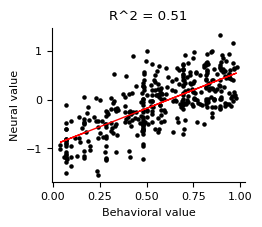

In [22]:
# plot neural value against behavioral value
neural_value = behav_new.V_t.values
behavioral_value = behav_new.V_t_behav.values

fig, ax = plt.subplots(figsize=(2.5, 2))
ax.scatter(behavioral_value, neural_value, color='k', s=5)
# fit linear regression
from sklearn.linear_model import LinearRegression
X = behavioral_value.reshape(-1, 1)
y = neural_value
reg = LinearRegression().fit(X, y)
y_pred = reg.predict(X)
ax.plot(X, y_pred, color='r', linewidth=1)
# get R^2
r2 = reg.score(X, y)
ax.set_xlabel('Behavioral value')
ax.set_ylabel('Neural value')
ax.set_title(f'R^2 = {r2:.2f}')

sns.despine()
# save figure

---
# Section 2: Analysis of the neural value representation

## Green red plot: Value evolves according to feedback

Spearman correlation (rho): 0.693, p-value: 4.3e-55
Spearman correlation positive sequences (rho): 0.300, p-value: 4.9e-06
Spearman correlation negative sequences (rho): 0.532, p-value: 1.5e-12


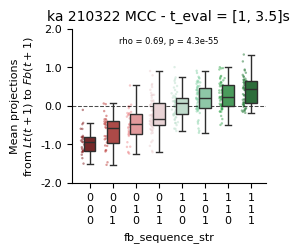

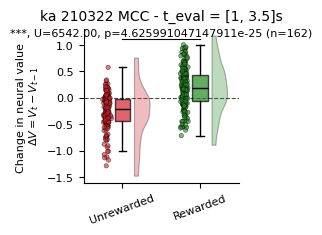

In [23]:
'''fig, ax = plot_projection_timepoint(behav_new, paper_format=True, ylim=None, show_datapoints=True)

plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

all_figs.append(fig)
'''

fig, ax = plot_Vt_per_sequence(behav_new, paper_format=True, ylim=None, show_datapoints=True, showfliers=False)
ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_Vt_per_sequence.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

fig, ax = create_r_style_plot(None, behav_new, 'feedback', 'dV', paper_format=True)
ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)
#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_feedback_dV.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

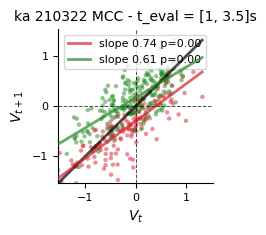

In [24]:
fig, ax = green_red_plot(behav_new, paper_format=True)
#plt.suptitle(f'{monkey} {session} {subregion}, t_fit = {t_interest_value} s', fontsize=10)

ax.set_title(f'{monkey} {session} {subregion} - t_eval = {t_interest_value}s', fontsize=10)

#fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_green_red.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

In [25]:
n_perms = 100

cpds_all = process_single_session(behav_new)
#cpds_all = add_corrected_pvals(pd.DataFrame([cpds_all]))
cpds_all = pd.DataFrame([cpds_all])
cpds_all

,cpd_R_1,pval_R_1,cpd_R_2,pval_R_2,cpd_R_3,pval_R_3,cpd_R_4,pval_R_4,cpd_R_5,pval_R_5,cpd_R_6,pval_R_6,cpd_R_7,pval_R_7,cpd_R_8,pval_R_8,monkey,session,subregion
0,46.489155,0.009901,23.101496,0.009901,11.002991,0.009901,6.892955,0.009901,4.137438,0.009901,1.745523,0.019802,0.027565,0.811881,0.139919,0.465347,ka,210322,MCC


In [50]:
def plot_cpds_history_neural_value(cpd_temp, null=None, ax=None, show_data=False):
    axis_original = ax
    if ax is None:
        h = 1.5  # in cm
        w = 1.5
        s = 10
        linewidth = 0.7
        fig, ax = plt.subplots(1, 1, figsize=(w, h))

    monkey, subregion = cpd_temp.monkey.unique()[0], cpd_temp.subregion.unique()[0]

    cpd_cols = [col for col in cpd_temp.columns if col.startswith('cpd_R_')]
    ymax = cpd_temp.groupby(['monkey', 'subregion'])[cpd_cols].mean().max().max()

    cpd_vals = cpd_temp[cpd_cols]
    cpd_means = cpd_vals.mean().values
    cpd_sems = cpd_vals.std().values

    # Determine significance for each point
    significance = []
    for i, reg in enumerate(cpd_cols):
        if null is None:
            pcol = f'pval_{"_".join(reg.split("_")[1:])}'
            pval = cpd_temp[pcol].values[0]
        else:
            pval = np.sum(null >= cpd_means[i]) / null.shape[0]
        significance.append(pval < 0.05)

    # Plot error bars (without markers)
    ax.errorbar(range(1, len(cpd_means)+1), cpd_means, yerr=cpd_sems, 
           fmt='-', color=COLORS[subregion], 
           label='session mean ± SEM', 
           capsize=2, zorder=1)
    
    # Plot markers separately based on significance
    for i, (mean, sig) in enumerate(zip(cpd_means, significance)):
        fillstyle = 'full' if sig else 'none'
        ax.plot(i+1, mean, 'o', 
                color=COLORS[subregion], 
                markeredgecolor='black', 
                markeredgewidth=0.5,
                fillstyle=fillstyle,
                markersize=6, 
                zorder=2)
    
    # Plot individual sessions
    if show_data:
        for i, col in enumerate(cpd_vals.columns):
            xpos = i+1 - 0.3
            jitter = np.random.normal(0, 0.05, size=len(cpd_vals[col]))
            ax.scatter(xpos + jitter, cpd_vals[col].values, color='black', alpha=0.2, zorder=0, s=2)

    ax.axhline(0, color='black', linestyle='dotted', alpha=0.3)
    ax.set_title(f'{monkey} {subregion}')
    ax.set_ylabel('CPD (%)')
    ax.set_xticks(range(1, len(cpd_cols)+1))
    ax.set_xticklabels([f't-{i}' for i in range(1, len(cpd_cols)+1)], rotation=45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if axis_original is None:
        return fig, ax

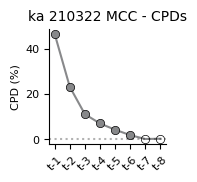

In [51]:
#null = create_permutation_null(behav_new, n_perms=100)

fig, axs = plot_cpds_history_neural_value(cpds_all)

# remove title from axes
axs.set_title(f'{monkey} {session} {subregion} - CPDs', fontsize=10)

fig.savefig(f'figs/neural_value/single_sessions/{monkey}_{session}_{subregion}_cpds.svg', bbox_inches='tight', transparent=True)
all_figs.append(fig)

---
# Save figs